
# 01 — Análise Exploratória de Dados (EDA)
### GalaxyNet — Classificador Morfológico de Galáxias


 O catálogo utilizado foi construído a partir da fusão entre os dados fotométricos e espectroscópicos do SDSS DR17 e as classificações morfológicas do Galaxy Zoo 2, totalizando 152 galáxias após o cruzamento espacial por coordenadas e a remoção de classificações incertas. As features disponíveis incluem magnitudes nas cinco bandas espectrais $(u, g, r, i, z)$, parâmetros morfológicos estruturais (raios de Petrosian, elipticidades, perfis de brilho), dados espectroscópicos (redshift, dispersão de velocidades) e índices de cor derivados.



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

# Configurações de visualização
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size']  = 11

# ── Caminhos relativos à raiz do projeto (notebooks está um nível abaixo) ──
BASE_DIR    = os.path.abspath(os.path.join(os.getcwd(), ".."))
CATALOG_CSV = os.path.join(BASE_DIR, "data", "processed", "merged_catalog.csv")
REPORTS_DIR = os.path.join(BASE_DIR, "reports")

os.makedirs(REPORTS_DIR, exist_ok=True)

print(f"Raiz do projeto : {BASE_DIR}")
print(f"Catálogo        : {CATALOG_CSV}")
print(f"Reports         : {REPORTS_DIR}")


Raiz do projeto : /home/luciano/Documentos/GalaxyNet/galaxy_classification
Catálogo        : /home/luciano/Documentos/GalaxyNet/galaxy_classification/data/processed/merged_catalog.csv
Reports         : /home/luciano/Documentos/GalaxyNet/galaxy_classification/reports


## 1. Carregamento dos Dados

In [2]:
df = pd.read_csv(CATALOG_CSV)

print(f"Shape do catálogo: {df.shape}")
print(f"\nColunas disponíveis:")
print(list(df.columns))


Shape do catálogo: (9239, 33)

Colunas disponíveis:
['objid', 'ra', 'dec', 'u', 'g', 'r', 'i', 'z', 'petroRad_r', 'petroR50_r', 'petroR90_r', 'deVAB_r', 'expAB_r', 'lnLDeV_r', 'lnLExp_r', 'lnLStar_r', 'fracDeV_r', 'redshift', 'zErr', 'velDisp', 'velDispErr', 'gz2_objid', 'gz2_ra', 'gz2_dec', 'total_votes_gz2', 't01_smooth_or_features_a01_smooth_fraction', 't01_smooth_or_features_a02_features_or_disk_fraction', 't01_smooth_or_features_a03_star_or_artifact_fraction', 't03_bar_a06_bar_fraction', 't03_bar_a07_no_bar_fraction', 't04_spiral_a08_spiral_fraction', 't04_spiral_a09_no_spiral_fraction', 'morph_class']


In [3]:
df.head()

,objid,ra,dec,u,g,r,i,z,petroRad_r,petroR50_r,...,gz2_dec,total_votes_gz2,t01_smooth_or_features_a01_smooth_fraction,t01_smooth_or_features_a02_features_or_disk_fraction,t01_smooth_or_features_a03_star_or_artifact_fraction,t03_bar_a06_bar_fraction,t03_bar_a07_no_bar_fraction,t04_spiral_a08_spiral_fraction,t04_spiral_a09_no_spiral_fraction,morph_class
0,1237648702972493979,197.154923,-1.252763,19.52571,17.74521,16.76546,16.32036,15.99769,5.207552,2.328935,...,-1.252742,141,0.822,0.111,0.067,0.0,1.0,0.5,0.5,Elliptical
1,1237648702972952662,198.136504,-1.241744,19.71973,17.73679,16.75908,16.32437,15.96696,3.630058,1.590797,...,-1.241711,143,0.891,0.043,0.065,0.5,0.5,0.0,1.0,Elliptical
2,1237648702973804683,200.166657,-1.101729,19.85966,17.89301,16.95394,16.55142,16.21367,3.651988,1.669565,...,-1.101735,158,0.826,0.109,0.065,0.2,0.8,0.0,1.0,Elliptical
3,1237648702973870138,200.291309,-1.201682,18.53104,17.42519,16.85697,16.46986,16.29665,3.253800,1.599572,...,-1.201682,133,0.977,0.023,0.000,0.0,1.0,0.0,1.0,Elliptical
4,1237648702973870300,200.334354,-1.132226,19.34652,17.49284,16.67980,16.31855,16.01687,3.960520,1.725911,...,-1.132226,163,0.841,0.136,0.023,0.2,0.8,0.0,1.0,Elliptical


## 2. Estatísticas Descritivas

In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
objid,9239.0,1.237651e+18,1.752105e+12,1.237646e+18,1.237650e+18,1.237651e+18,1.237652e+18,1.237655e+18
ra,9239.0,1.784545e+02,3.846511e+01,4.610768e+01,1.454186e+02,1.787650e+02,2.096500e+02,3.165429e+02
dec,9239.0,2.094243e+01,2.649877e+01,-3.740871e+00,3.054717e-01,3.001544e+00,5.146069e+01,6.866448e+01
u,9239.0,1.898735e+01,8.297171e-01,1.582069e+01,1.848566e+01,1.911552e+01,1.959615e+01,2.464300e+01
g,9239.0,1.721892e+01,7.008858e-01,1.459632e+01,1.686627e+01,1.738392e+01,1.771735e+01,2.529791e+01
r,9239.0,1.633475e+01,6.362198e-01,1.401194e+01,1.602421e+01,1.651226e+01,1.681388e+01,1.768578e+01
i,9239.0,1.591506e+01,6.322926e-01,1.358058e+01,1.560751e+01,1.608642e+01,1.638930e+01,1.735671e+01
z,9239.0,1.559786e+01,6.440374e-01,1.323020e+01,1.528744e+01,1.575892e+01,1.606501e+01,2.411752e+01
petroRad_r,9239.0,6.632643e+00,3.404179e+00,1.564935e+00,4.513063e+00,5.720205e+00,7.703943e+00,6.707412e+01
petroR50_r,9239.0,2.878582e+00,1.478041e+00,7.921408e-01,1.977507e+00,2.464867e+00,3.274065e+00,3.671796e+01


## 3. Verificação de Valores Nulos

In [5]:
nulos     = df.isnull().sum()
nulos_pct = (nulos / len(df) * 100).round(2)

resumo = pd.DataFrame({'Valores Nulos': nulos, '% do Total': nulos_pct})

if resumo['Valores Nulos'].sum() > 0:
    print(resumo[resumo['Valores Nulos'] > 0].to_string())
else:
    print("Nenhum valor nulo encontrado no catálogo.")


Nenhum valor nulo encontrado no catálogo.


## 4. Distribuição das Classes Morfológicas




In [6]:
contagem = df['morph_class'].value_counts()
print("Distribuição de classes:")
print(contagem.to_string())
print(f"\nTotal de galáxias: {len(df)}")


Distribuição de classes:
morph_class
Elliptical    7742
Spiral        1232
Irregular      265

Total de galáxias: 9239


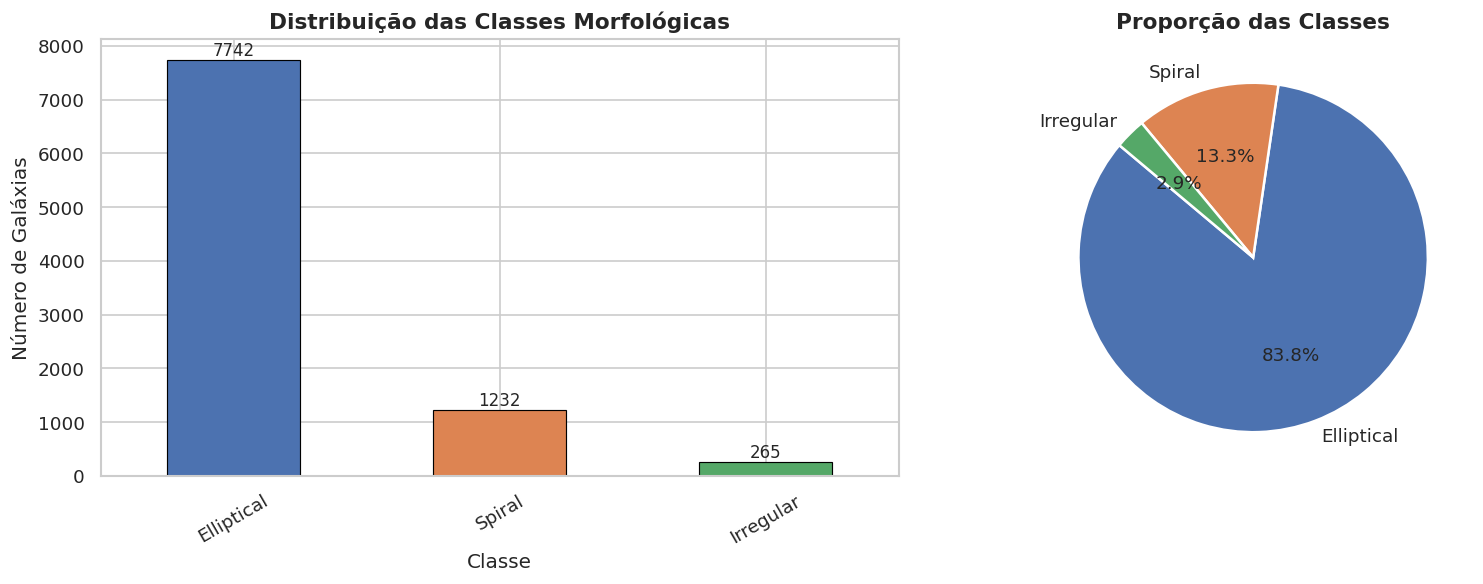

fig01 salva.


In [7]:
# ── Gráfico 1: Distribuição de classes morfológicas ──────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

palette = sns.color_palette("deep", len(contagem))

contagem.plot(kind='bar', ax=axes[0], color=palette, edgecolor='black', linewidth=0.7)
axes[0].set_title('Distribuição das Classes Morfológicas', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Classe')
axes[0].set_ylabel('Número de Galáxias')
axes[0].tick_params(axis='x', rotation=30)
for bar, valor in zip(axes[0].patches, contagem):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 str(valor), ha='center', va='bottom', fontsize=10)

axes[1].pie(contagem, labels=contagem.index, autopct='%1.1f%%',
            colors=palette, startangle=140,
            wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
axes[1].set_title('Proporção das Classes', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(REPORTS_DIR, 'fig01_distribuicao_classes.png'), bbox_inches='tight')
plt.show()
print("fig01 salva.")


## 5. Distribuição do Redshift
O redshift $z$ indica a distância cosmológica da galáxia. Filtramos $0.02 \leq z \leq 0.25$ na query SQL.



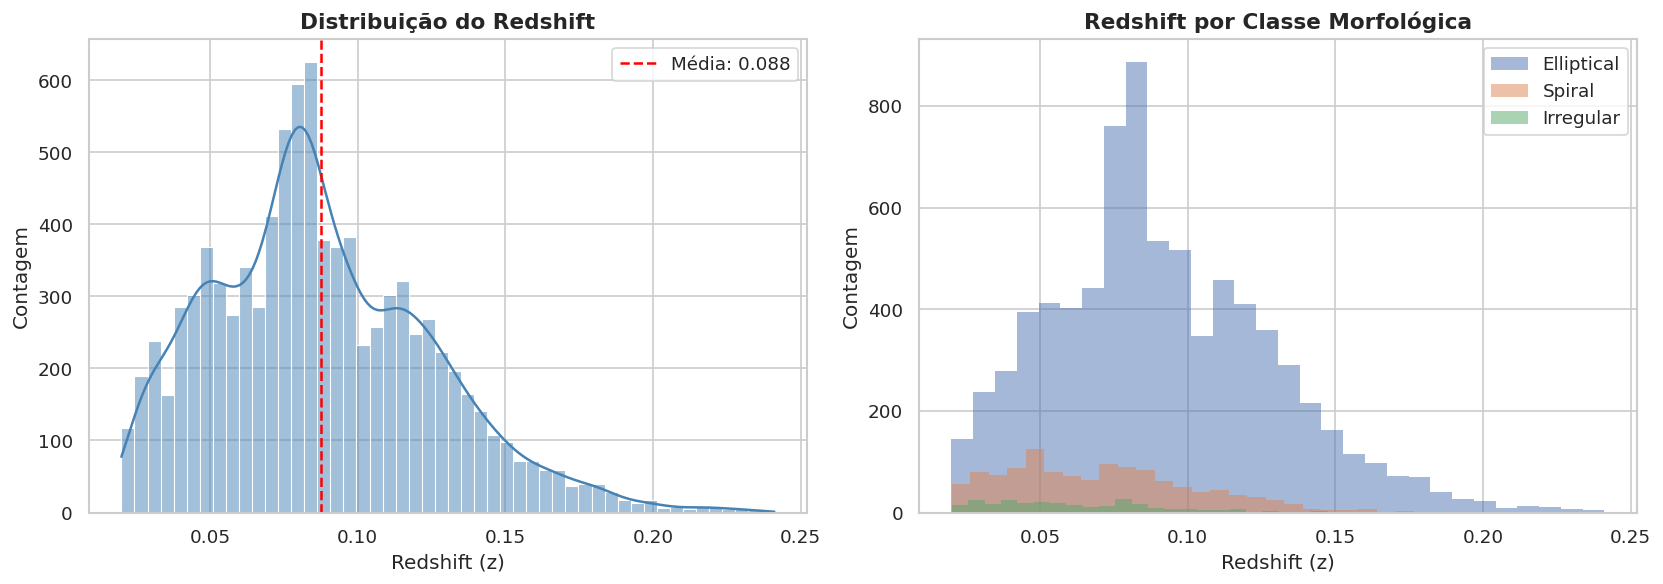

fig02 salva.


In [8]:
# ── Gráfico 2: Distribuição de redshift ──────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df['redshift'], bins=50, kde=True, ax=axes[0], color='steelblue')
axes[0].set_title('Distribuição do Redshift', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Redshift (z)')
axes[0].set_ylabel('Contagem')
axes[0].axvline(df['redshift'].mean(), color='red', linestyle='--',
                label=f"Média: {df['redshift'].mean():.3f}")
axes[0].legend()

classes  = df['morph_class'].unique()
palette2 = sns.color_palette("deep", len(classes))
for cls, cor in zip(classes, palette2):
    axes[1].hist(df[df['morph_class'] == cls]['redshift'],
                 bins=30, alpha=0.5, label=cls, edgecolor='none', color=cor)
axes[1].set_title('Redshift por Classe Morfológica', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Redshift (z)')
axes[1].set_ylabel('Contagem')
axes[1].legend()

plt.tight_layout()
plt.savefig(os.path.join(REPORTS_DIR, 'fig02_distribuicao_redshift.png'), bbox_inches='tight')
plt.show()
print("fig02 salva.")


## 6. Cálculo dos Índices de Cor
Índices de cor são diferenças entre magnitudes em bandas adjacentes.
- Galáxias **elípticas** tendem a ser mais vermelhas (maior $g-r$)
- Galáxias **espirais** tendem a ser mais azuis (menor $g-r$)


In [9]:
df['u_g'] = df['u'] - df['g']
df['g_r'] = df['g'] - df['r']
df['r_i'] = df['r'] - df['i']
df['i_z'] = df['i'] - df['z']
df['concentration'] = df['petroR90_r'] / df['petroR50_r'].replace(0, np.nan)

print("Índices de cor calculados:")
print(df[['u_g', 'g_r', 'r_i', 'i_z', 'concentration']].describe().round(3))


Índices de cor calculados:
            u_g       g_r       r_i       i_z  concentration
count  9239.000  9239.000  9239.000  9239.000       9239.000
mean      1.768     0.884     0.420     0.317          2.816
std       0.345     0.226     0.058     0.114          0.409
min      -7.157     0.121    -0.248    -8.639          1.116
25%       1.582     0.781     0.396     0.292          2.524
50%       1.866     0.908     0.426     0.331          2.901
75%       1.980     1.001     0.453     0.359          3.135
max       7.731     9.316     0.704     1.089          7.164


## 7. Diagrama Cor-Magnitude
O diagrama cor-magnitude (g-r vs r) é uma ferramenta clássica em astronomia extragaláctica.


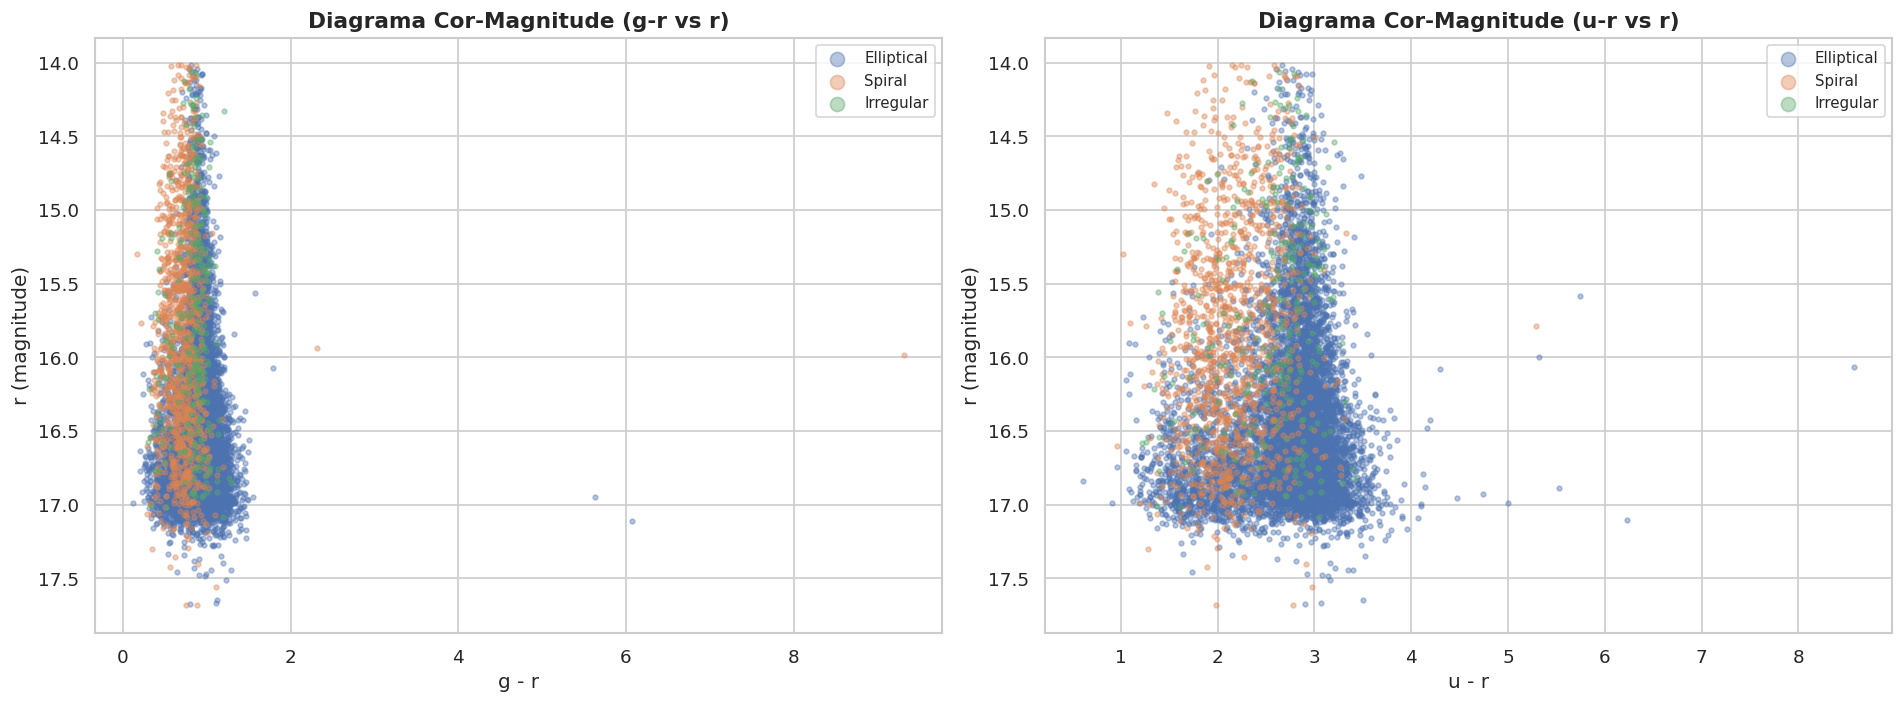

fig03 salva.


In [10]:
# ── Gráfico 3: Diagrama Cor-Magnitude (Listing 7 do PDF) ─────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for cls, cor in zip(classes, palette2):
    sub = df[df['morph_class'] == cls]
    axes[0].scatter(sub['g'] - sub['r'], sub['r'], label=cls, alpha=0.4, s=8, color=cor)
axes[0].invert_yaxis()
axes[0].set_title('Diagrama Cor-Magnitude (g-r vs r)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('g - r')
axes[0].set_ylabel('r (magnitude)')
axes[0].legend(markerscale=3, fontsize=9)

for cls, cor in zip(classes, palette2):
    sub = df[df['morph_class'] == cls]
    axes[1].scatter(sub['u'] - sub['r'], sub['r'], label=cls, alpha=0.4, s=8, color=cor)
axes[1].invert_yaxis()
axes[1].set_title('Diagrama Cor-Magnitude (u-r vs r)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('u - r')
axes[1].set_ylabel('r (magnitude)')
axes[1].legend(markerscale=3, fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(REPORTS_DIR, 'fig03_diagrama_cor_magnitude.png'), bbox_inches='tight')
plt.show()
print("fig03 salva.")


## 8. Distribuição dos Índices de Cor por Classe

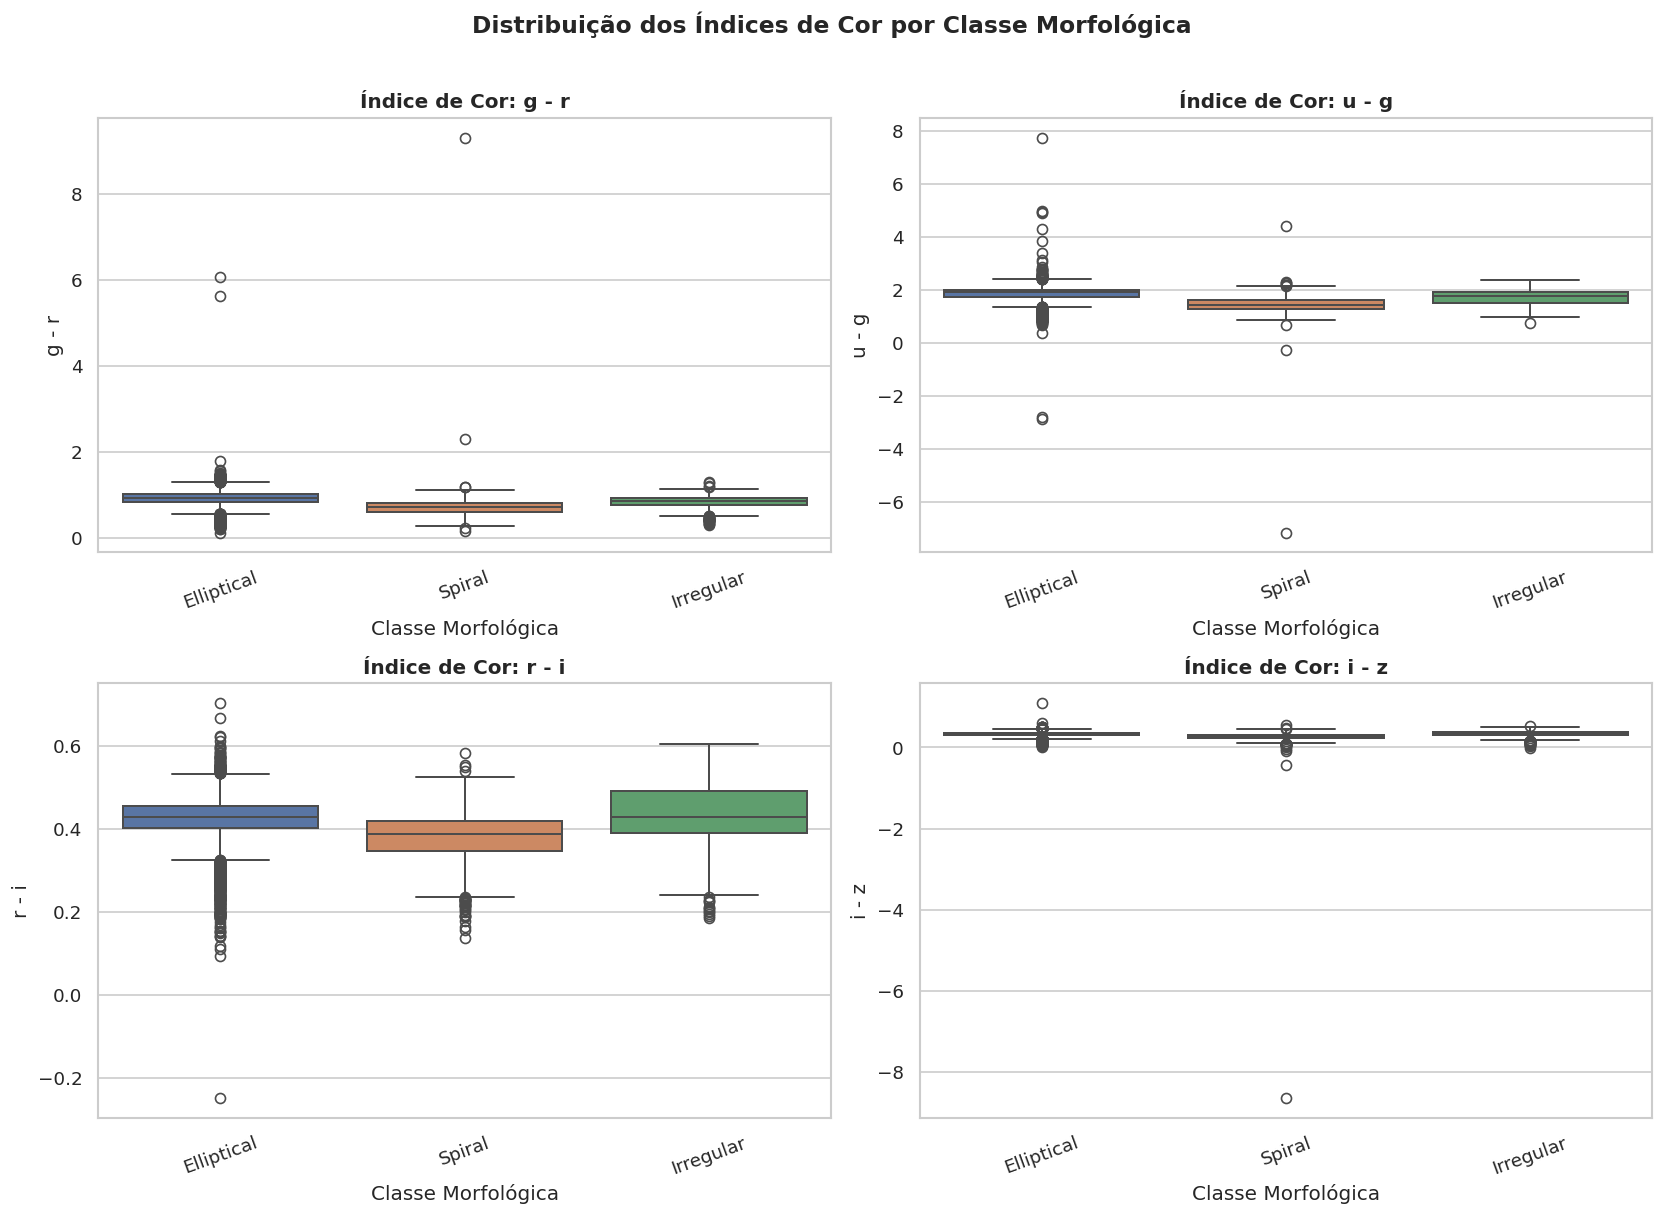

fig04 salva.


In [11]:
# ── Gráfico 4: Boxplots de índices de cor por classe ─────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, cor, titulo in zip(axes.flatten(),
                            ['g_r', 'u_g', 'r_i', 'i_z'],
                            ['g - r', 'u - g', 'r - i', 'i - z']):
    sns.boxplot(data=df, x='morph_class', y=cor, ax=ax,
                palette="deep", linewidth=1.2)
    ax.set_title(f'Índice de Cor: {titulo}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Classe Morfológica')
    ax.set_ylabel(titulo)
    ax.tick_params(axis='x', rotation=20)

plt.suptitle('Distribuição dos Índices de Cor por Classe Morfológica',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(REPORTS_DIR, 'fig04_boxplots_cor_por_classe.png'), bbox_inches='tight')
plt.show()
print("fig04 salva.")


## 9. Matriz de Correlação das Features

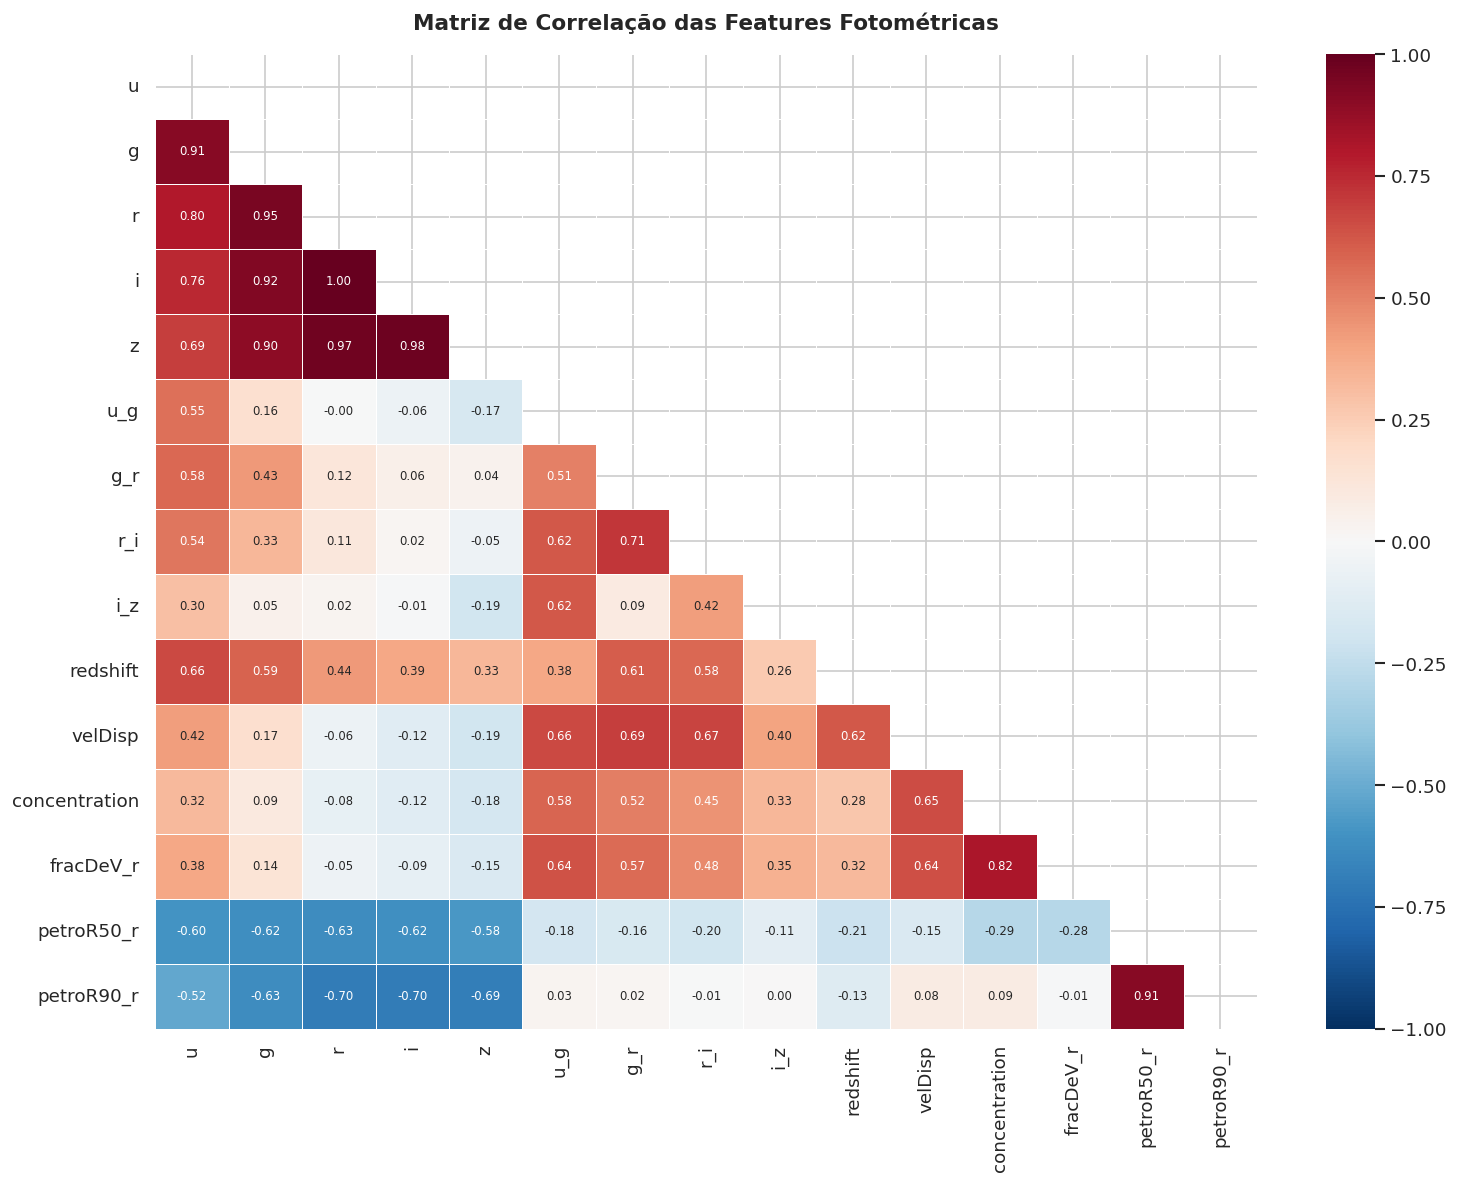

fig05 salva.


In [12]:
# ── Gráfico 5: Heatmap de correlação ─────────────────────────────────────────
features_corr = ['u', 'g', 'r', 'i', 'z',
                 'u_g', 'g_r', 'r_i', 'i_z',
                 'redshift', 'velDisp',
                 'concentration', 'fracDeV_r',
                 'petroR50_r', 'petroR90_r']

corr = df[features_corr].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

fig, ax = plt.subplots(figsize=(13, 10))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, linewidths=0.5,
            annot_kws={'size': 7}, ax=ax)
ax.set_title('Matriz de Correlação das Features Fotométricas',
             fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig(os.path.join(REPORTS_DIR, 'fig05_matriz_correlacao.png'), bbox_inches='tight')
plt.show()
print("fig05 salva.")


## 10. Dispersão de Velocidades vs Redshift
A dispersão de velocidades (`velDisp`) é um indicador da massa da galáxia.


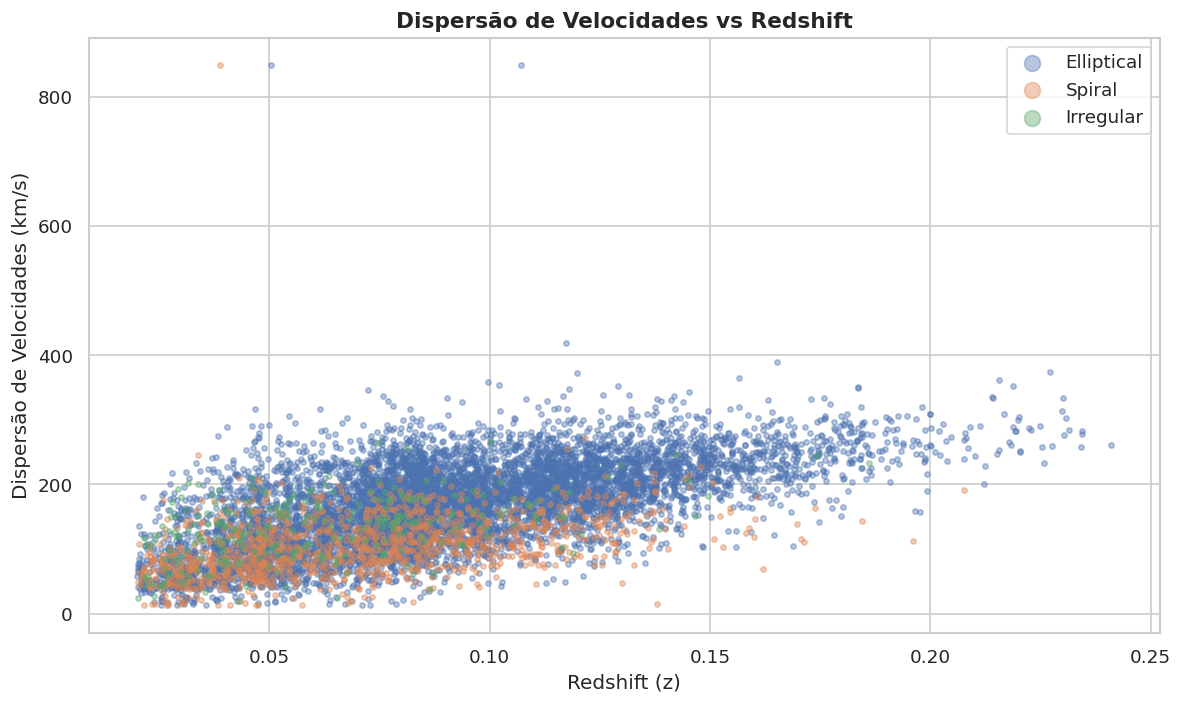

fig06 salva.


In [13]:
# ── Gráfico 6: velDisp vs redshift por classe ────────────────────────────────
df_vel = df[df['velDisp'] > 0].copy()

fig, ax = plt.subplots(figsize=(10, 6))
for cls, cor in zip(classes, palette2):
    sub = df_vel[df_vel['morph_class'] == cls]
    ax.scatter(sub['redshift'], sub['velDisp'],
               label=cls, alpha=0.4, s=10, color=cor)

ax.set_title('Dispersão de Velocidades vs Redshift', fontsize=13, fontweight='bold')
ax.set_xlabel('Redshift (z)')
ax.set_ylabel('Dispersão de Velocidades (km/s)')
ax.legend(markerscale=3)
plt.tight_layout()
plt.savefig(os.path.join(REPORTS_DIR, 'fig06_veldisp_redshift.png'), bbox_inches='tight')
plt.show()
print("fig06 salva.")


## 11. Resumo da EDA

In [14]:
print("=" * 55)
print("RESUMO DA ANÁLISE EXPLORATÓRIA DE DADOS")
print("=" * 55)
print(f"Total de galáxias         : {len(df)}")
print(f"Número de features        : {df.shape[1]}")
print(f"Valores nulos             : {df.isnull().sum().sum()}")
print()
print("Distribuição de classes:")
for cls, n in df['morph_class'].value_counts().items():
    print(f"  {cls:<12}: {n:>5} ({n/len(df)*100:.1f}%)")
print()
print("Estatísticas do redshift:")
print(f"  Mínimo : {df['redshift'].min():.4f}")
print(f"  Máximo : {df['redshift'].max():.4f}")
print(f"  Média  : {df['redshift'].mean():.4f}")
print(f"  Mediana: {df['redshift'].median():.4f}")
print()
print("Índices de cor médios por classe:")
print(df.groupby('morph_class')[['g_r','u_g','r_i']].mean().round(3).to_string())
print()
print("Figuras salvas em reports/:")
for i, nome in enumerate(['fig01_distribuicao_classes.png',
                           'fig02_distribuicao_redshift.png',
                           'fig03_diagrama_cor_magnitude.png',
                           'fig04_boxplots_cor_por_classe.png',
                           'fig05_matriz_correlacao.png',
                           'fig06_veldisp_redshift.png'], 1):
    print(f"  {i}. {nome}")


RESUMO DA ANÁLISE EXPLORATÓRIA DE DADOS
Total de galáxias         : 9239
Número de features        : 38
Valores nulos             : 0

Distribuição de classes:
  Elliptical  :  7742 (83.8%)
  Spiral      :  1232 (13.3%)
  Irregular   :   265 (2.9%)

Estatísticas do redshift:
  Mínimo : 0.0201
  Máximo : 0.2411
  Média  : 0.0878
  Mediana: 0.0832

Índices de cor médios por classe:
               g_r    u_g    r_i
morph_class                     
Elliptical   0.914  1.822  0.426
Irregular    0.824  1.707  0.427
Spiral       0.707  1.447  0.380

Figuras salvas em reports/:
  1. fig01_distribuicao_classes.png
  2. fig02_distribuicao_redshift.png
  3. fig03_diagrama_cor_magnitude.png
  4. fig04_boxplots_cor_por_classe.png
  5. fig05_matriz_correlacao.png
  6. fig06_veldisp_redshift.png
